In [1]:
import pandas as pd

In [19]:
dataset= pd.read_csv(r'C:\Users\farhe\Documents\HisabDo Internship Tasks\student_performance.csv')

In [20]:
dataset.head(3)

,Student Name,Age,Gender,Course,Attendance,Assignment Score,Midterm Score,Final Score
0,Ali,19,Male,Computer Science,96,98,49,56
1,Sara,18,Female,Software Engineering,91,98,73,70
2,Ahmed,23,Male,AI,84,100,58,46


In [4]:
dataset= dataset.drop(["Age", "Gender", "Course"], axis=1)

In [5]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Student Name      30 non-null     str  
 1   Attendance        30 non-null     int64
 2   Assignment Score  30 non-null     int64
 3   Midterm Score     30 non-null     int64
 4   Final Score       30 non-null     int64
dtypes: int64(4), str(1)
memory usage: 1.3 KB


In [6]:
dataset.isnull().sum()

Student Name        0
Attendance          0
Assignment Score    0
Midterm Score       0
Final Score         0
dtype: int64

In [7]:
# no null values in data

In [8]:
x= dataset[["Attendance", "Assignment Score", "Midterm Score", "Final Score"]]

In [9]:
dataset["Pass"]= dataset["Final Score"]>50

In [10]:
y= dataset["Pass"]

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.3, random_state=42)

In [79]:
dt= DecisionTreeClassifier()

In [80]:
dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [81]:
dt_pred= dt.predict(x_test)

In [21]:
dataset.head(2)

,Student Name,Age,Gender,Course,Attendance,Assignment Score,Midterm Score,Final Score
0,Ali,19,Male,Computer Science,96,98,49,56
1,Sara,18,Female,Software Engineering,91,98,73,70


In [42]:
#data cleaning
dataset= dataset.drop(["Student Name", "Age", "Gender", "Course"], axis=1)

In [43]:
# drop duplicate values
dataset = dataset.drop_duplicates()

In [44]:
dataset["Pass"]= dataset["Final Score"]>50
X= dataset.drop("Pass", axis=1)
Y= dataset["Pass"]

In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
ss= StandardScaler()
X_scaled= ss.fit_transform(X)

In [84]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [85]:
#hyperparameter tuning using GridSearhCV
from sklearn.model_selection import GridSearchCV

In [86]:
params = {"criterion": ["gini", "entropy", "log_loss"],
    "splitter":["best", "random"],
    "max_depth": [i for i in range(2, 21)]}

In [87]:
gd = GridSearchCV(DecisionTreeClassifier(), param_grid= params, cv=5)
gd.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [2, 3, ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [88]:
gd.best_params_

{'criterion': 'gini', 'max_depth': 2, 'splitter': 'best'}

In [89]:
#tuned decision tree
tuned_model= gd.best_estimator_
tuned_model_pred= tuned_model.predict(X_test)

In [90]:
print("Previous Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))
print("ROC-AUC:", roc_auc_score(y_test, dt_pred))

print()

print("Tuned Decision Tree")
print("Accuracy:", accuracy_score(Y_test, tuned_model_pred))
print("Precision:", precision_score(Y_test, tuned_model_pred))
print("Recall:", recall_score(Y_test, tuned_model_pred))
print("F1 Score:", f1_score(Y_test, tuned_model_pred))
print("ROC-AUC:", roc_auc_score(Y_test, tuned_model_pred))

Previous Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0

Tuned Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


In [100]:
results= pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Previous Model": [accuracy_score(y_test, dt_pred),
        precision_score(y_test, dt_pred),
        recall_score(y_test, dt_pred),
        f1_score(y_test, dt_pred),
        roc_auc_score(y_test, dt_pred)],
    "Tuned Model": [
        accuracy_score(Y_test, tuned_model_pred),
        precision_score(Y_test, tuned_model_pred),
        recall_score(Y_test, tuned_model_pred),
        f1_score(Y_test, tuned_model_pred),
        roc_auc_score(Y_test, tuned_model_pred)]})

print("MODELS COMPARISON")
print("\n", results)

MODELS COMPARISON

       Metric  Previous Model  Tuned Model
0   Accuracy             1.0          1.0
1  Precision             1.0          1.0
2     Recall             1.0          1.0
3   F1 Score             1.0          1.0
4    ROC-AUC             1.0          1.0


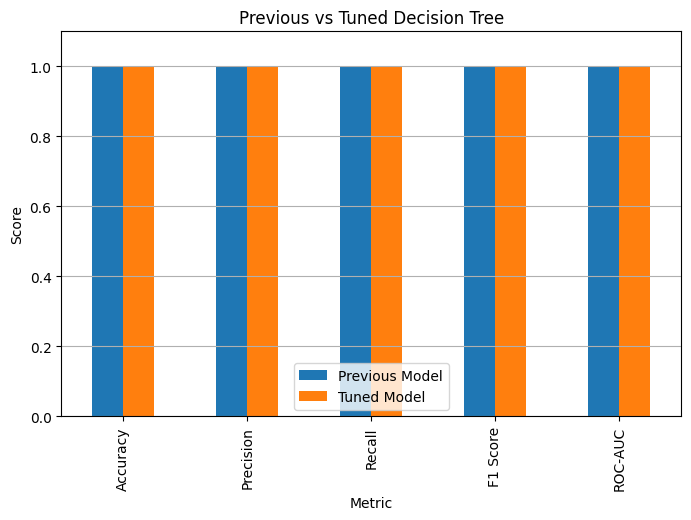

In [104]:
#graph comparison between both models

results.set_index("Metric").plot(kind="bar", figsize=(8,5))
plt.title("Previous vs Tuned Decision Tree")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.grid(axis="y")
plt.savefig('previous_tuned_decision_tree')
plt.show()